## 1. Setup and import

In [57]:
import ast
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

---
## 2. Load and merge dataset

In [58]:
metadata = pd.read_csv("../data/dataset/movies_metadata.csv", low_memory=False)
ratings = pd.read_csv("../data/dataset/ratings_small.csv")
links = pd.read_csv("../data/dataset/links_small.csv")

#Làm sạch metadata
metadata["id"] = pd.to_numeric(metadata["id"], errors="coerce")
metadata.dropna(subset=["id"], inplace=True)
metadata["id"] = metadata["id"].astype(int)

#Merge
METADATA_COLS = ["id", "title", "genres", "release_date", "runtime", "budget", "revenue", "overview"]

df = (ratings.merge(links, on="movieId", how="left")
            .merge(metadata[METADATA_COLS], left_on="tmdbId", right_on="id", how="left"))

print(f"ratings   : {ratings.shape}")
print(f"metadata  : {metadata.shape}")
print(f"links     : {links.shape}")
print(f"merged df : {df.shape}")
df.head(3)

ratings   : (100004, 4)
metadata  : (45463, 24)
links     : (9125, 3)
merged df : (100044, 14)


,userId,movieId,rating,timestamp,imdbId,tmdbId,id,title,genres,release_date,runtime,budget,revenue,overview
0,1,31,2.5,1260759144,112792,9909.0,9909.0,Dangerous Minds,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",1995-08-11,99.0,0,180000000.0,Former Marine Louanne Johnson lands a gig teac...
1,1,1029,3.0,1260759179,33563,11360.0,11360.0,Dumbo,"[{'id': 16, 'name': 'Animation'}, {'id': 10751...",1941-10-22,64.0,812000,1600000.0,Dumbo is a baby elephant born with oversized e...
2,1,1061,3.0,1260759182,117665,819.0,819.0,Sleepers,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",1996-10-18,147.0,44000000,165615285.0,Two gangsters seek revenge on the state jail w...


---
## 3. Data overview

### 3.1 Cấu trúc dữ liệu

In [59]:
print("── ratings ──")
print(ratings.dtypes)
print("── metadata (sample cols) ──")
print(metadata[["id","title","genres","overview","release_date"]].dtypes)

── ratings ──
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object
── metadata (sample cols) ──
id              int64
title             str
genres            str
overview          str
release_date      str
dtype: object


### 3.2 Missing values

In [60]:
def missing_report(frame, name):
    miss = frame.isnull().sum()
    pct  = (miss / len(frame) * 100).round(2)
    report = pd.DataFrame({"missing": miss, "pct_%": pct})
    report = report[report["missing"] > 0].sort_values("pct_%", ascending=False)
    print(report if not report.empty else "No missing values")

missing_report(ratings,  "ratings_small")
missing_report(metadata, "movies_metadata")
missing_report(links,    "links_small")
missing_report(df,       "merged df")

No missing values
                       missing  pct_%
belongs_to_collection    40972  90.12
homepage                 37684  82.89
tagline                  25051  55.10
overview                   954   2.10
poster_path                386   0.85
runtime                    260   0.57
release_date                87   0.19
status                      84   0.18
imdb_id                     17   0.04
original_language           11   0.02
popularity                   3   0.01
revenue                      3   0.01
production_countries         3   0.01
production_companies         3   0.01
spoken_languages             3   0.01
title                        3   0.01
video                        3   0.01
vote_average                 3   0.01
vote_count                   3   0.01
        missing  pct_%
tmdbId       13   0.14
              missing  pct_%
overview          208   0.21
release_date      194   0.19
id                194   0.19
genres            194   0.19
title             194   0.19
bu

### 3.3 Duplicates & Basic Statistics

In [61]:
print(f"Duplicate rows in ratings : {ratings.duplicated().sum()}")
print(f"Duplicate rows in metadata: {metadata.duplicated().sum()}")
print("── ratings describe ──")
display(ratings.describe())

Duplicate rows in ratings : 0
Duplicate rows in metadata: 17
── ratings describe ──


,userId,movieId,rating,timestamp
count,100004.000000,100004.000000,100004.000000,1.000040e+05
mean,347.011310,12548.664363,3.543608,1.129639e+09
std,195.163838,26369.198969,1.058064,1.916858e+08
min,1.000000,1.000000,0.500000,7.896520e+08
25%,182.000000,1028.000000,3.000000,9.658478e+08
50%,367.000000,2406.500000,4.000000,1.110422e+09
75%,520.000000,5418.000000,4.000000,1.296192e+09
max,671.000000,163949.000000,5.000000,1.476641e+09


---
## 4. Feature Engineering

In [62]:
#Parse genres
def parse_genres(genre_str):
    try:
        return [g["name"] for g in ast.literal_eval(genre_str)]
    except Exception:
        return []

df["genre_list"] = df["genres"].apply(parse_genres)

#Temporal features
df["rating_year"]   = pd.to_datetime(df["timestamp"], unit="s").dt.year
df["rating_month"]  = pd.to_datetime(df["timestamp"], unit="s").dt.month
df["release_year"]  = pd.to_datetime(df["release_date"], errors="coerce").dt.year

#Numeric columns
for col in ["budget", "revenue", "runtime"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[["rating_year","release_year","genre_list"]].head(3))

   rating_year  release_year                genre_list
0         2009        1995.0            [Drama, Crime]
1         2009        1941.0       [Animation, Family]
2         2009        1996.0  [Crime, Drama, Thriller]


---
## 5. EDA Figures

### 5.1 Rating Distribution

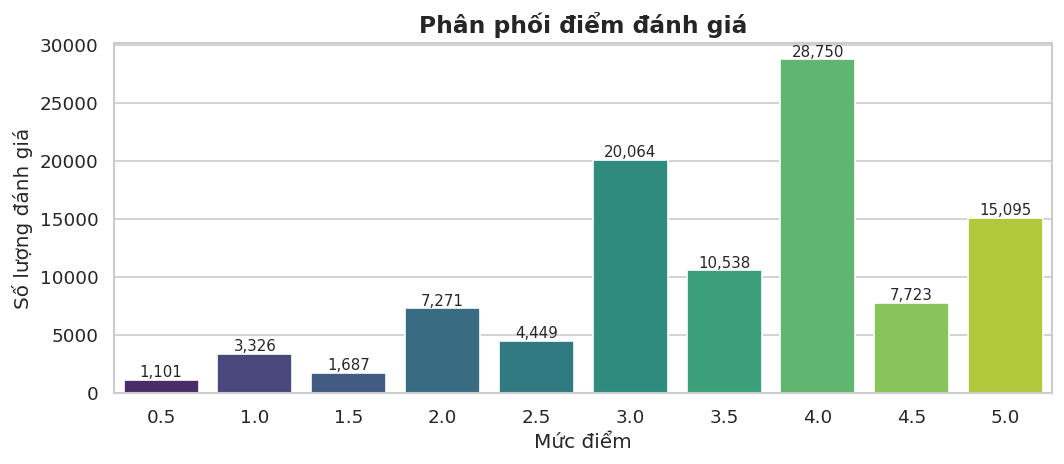

Rating trung bình : 3.544
Tỷ lệ rating ≥ 4  : 51.6%
Tỷ lệ rating ≤ 2  : 13.4%


In [63]:
fig, ax = plt.subplots(figsize=(9, 4))

order = sorted(ratings["rating"].unique())
sns.countplot(x="rating", data=ratings, order=order, palette="viridis", ax=ax)

ax.set_title("Phân phối điểm đánh giá", fontsize=14, fontweight="bold")
ax.set_xlabel("Mức điểm")
ax.set_ylabel("Số lượng đánh giá")

for bar in ax.patches:
    ax.annotate(f"{int(bar.get_height()):,}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Rating trung bình : {ratings['rating'].mean():.3f}")
print(f"Tỷ lệ rating ≥ 4  : {(ratings['rating'] >= 4).mean():.1%}")
print(f"Tỷ lệ rating ≤ 2  : {(ratings['rating'] <= 2).mean():.1%}")

### 5.2 Long Tail

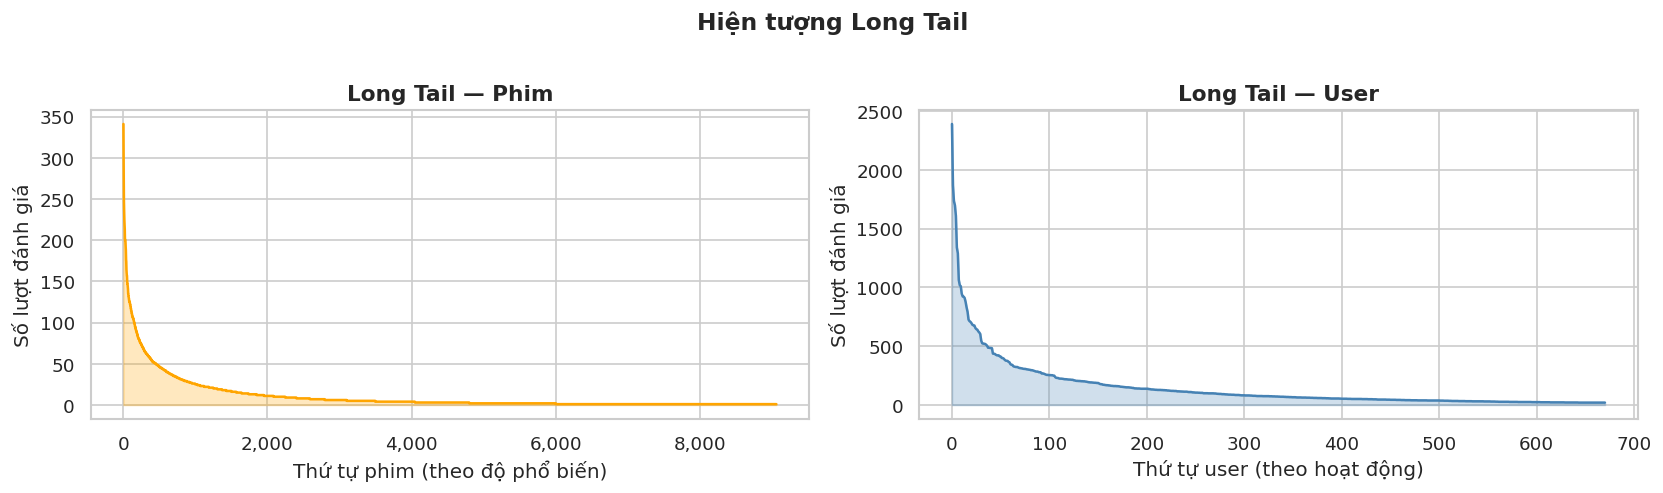

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#Long tail by movie
movie_counts = (ratings.groupby("movieId")["rating"]
                .count().sort_values(ascending=False))
ax = axes[0]
ax.plot(range(len(movie_counts)), movie_counts.values, color="orange")
ax.fill_between(range(len(movie_counts)), movie_counts.values,
                color="orange", alpha=0.25)
ax.set_title("Long Tail — Phim", fontsize=13, fontweight="bold")
ax.set_xlabel("Thứ tự phim (theo độ phổ biến)")
ax.set_ylabel("Số lượt đánh giá")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))

#Long tail by user
user_counts = (ratings.groupby("userId")["rating"]
               .count().sort_values(ascending=False))
ax = axes[1]
ax.plot(range(len(user_counts)), user_counts.values, color="steelblue")
ax.fill_between(range(len(user_counts)), user_counts.values,
                color="steelblue", alpha=0.25)
ax.set_title("Long Tail — User", fontsize=13, fontweight="bold")
ax.set_xlabel("Thứ tự user (theo hoạt động)")
ax.set_ylabel("Số lượt đánh giá")

plt.suptitle("Hiện tượng Long Tail", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Phân phối hoạt động user và movies

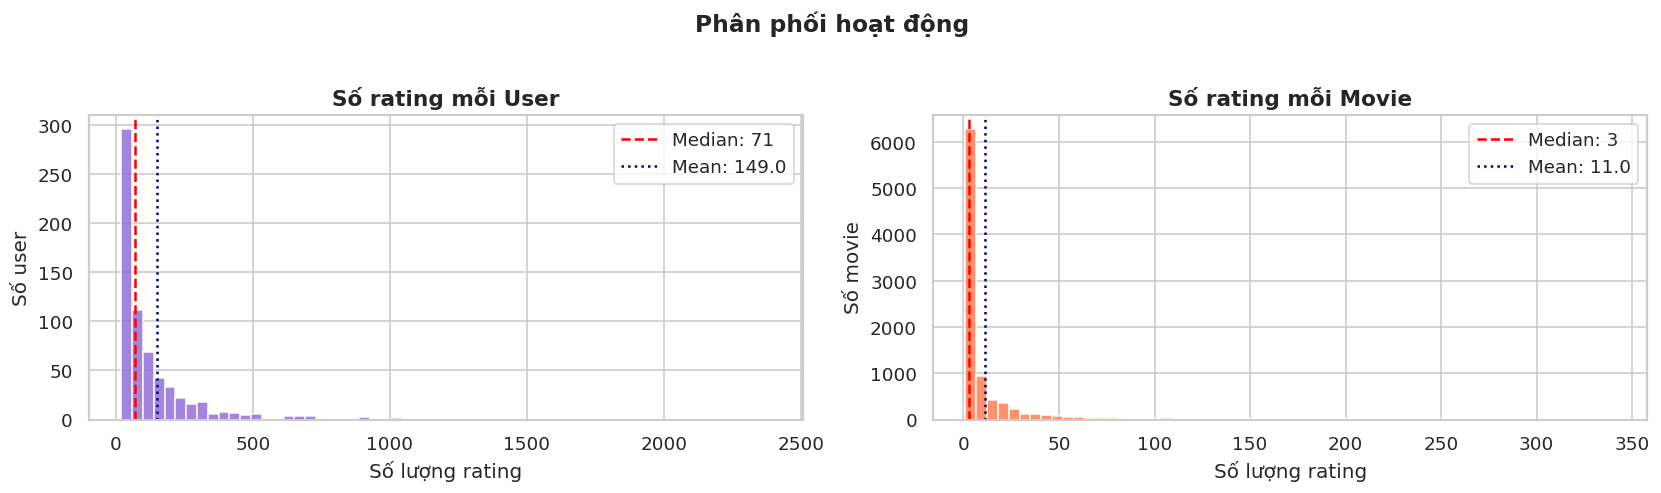

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

user_activity  = ratings.groupby("userId")["rating"].count()
movie_activity = ratings.groupby("movieId")["rating"].count()

for ax, data, color, label in zip(
        axes,
        [user_activity, movie_activity],
        ["mediumpurple", "coral"],
        ["User", "Movie"]):
    ax.hist(data, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=1.5,
               label=f"Median: {data.median():.0f}")
    ax.axvline(data.mean(),   color="navy", linestyle=":",  linewidth=1.5,
               label=f"Mean: {data.mean():.1f}")
    ax.set_title(f"Số rating mỗi {label}", fontsize=13, fontweight="bold")
    ax.set_xlabel(f"Số lượng rating")
    ax.set_ylabel(f"Số {label.lower()}")
    ax.legend()

plt.suptitle("Phân phối hoạt động", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Top 10 genre phổ biến

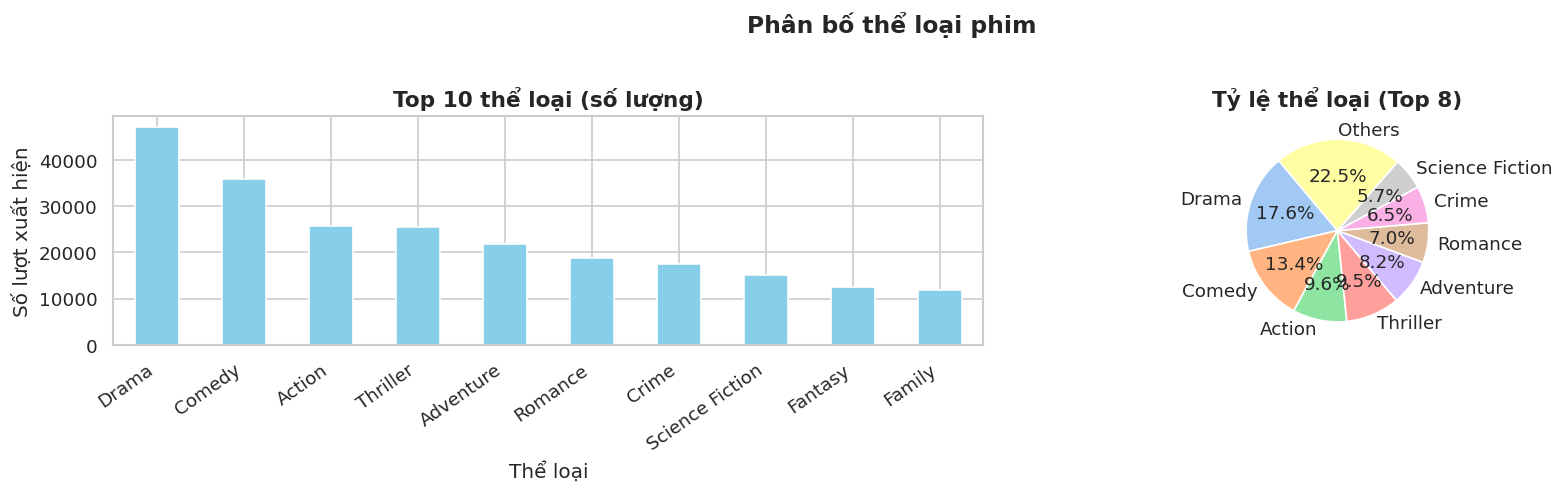

In [66]:
all_genres   = [g for sub in df["genre_list"] for g in sub]
genre_counts = pd.Series(all_genres).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Bar chart
genre_counts.head(10).plot(kind="bar", ax=axes[0],
                           color="skyblue", edgecolor="white")
axes[0].set_title("Top 10 thể loại (số lượng)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Thể loại")
axes[0].set_ylabel("Số lượt xuất hiện")
axes[0].set_xticklabels(genre_counts.head(10).index, rotation=35, ha="right")

# Pie chart
top8   = genre_counts.head(8)
others = pd.Series({"Others": genre_counts[8:].sum()})
pie_data = pd.concat([top8, others])
axes[1].pie(pie_data, labels=pie_data.index, autopct="%1.1f%%",
            startangle=130, colors=sns.color_palette("pastel", len(pie_data)))
axes[1].set_title("Tỷ lệ thể loại (Top 8)", fontsize=13, fontweight="bold")

plt.suptitle("Phân bố thể loại phim", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 5.5 Xu hướng đánh giá theo thời gian

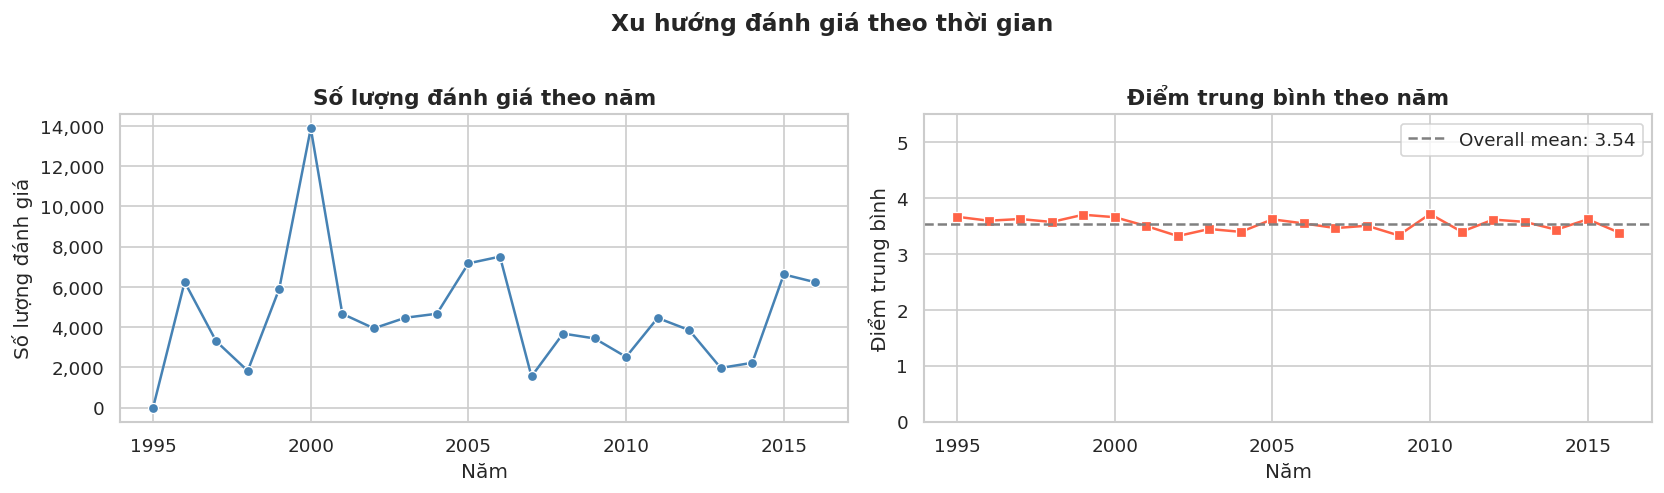

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Ratings per year
ratings_per_year = df.groupby("rating_year")["rating"].count()
sns.lineplot(x=ratings_per_year.index, y=ratings_per_year.values,
             marker="o", color="steelblue", ax=axes[0])
axes[0].set_title("Số lượng đánh giá theo năm", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Năm")
axes[0].set_ylabel("Số lượng đánh giá")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))

# Avg rating per year
avg_per_year = df.groupby("rating_year")["rating"].mean()
sns.lineplot(x=avg_per_year.index, y=avg_per_year.values,
             marker="s", color="tomato", ax=axes[1])
axes[1].set_title("Điểm trung bình theo năm", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Năm")
axes[1].set_ylabel("Điểm trung bình")
axes[1].set_ylim(0, 5.5)
axes[1].axhline(df["rating"].mean(), linestyle="--", color="gray",
                label=f"Overall mean: {df['rating'].mean():.2f}")
axes[1].legend()

plt.suptitle("Xu hướng đánh giá theo thời gian", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5.6 Top phim được đánh giá nhiều nhất & điểm cao nhất

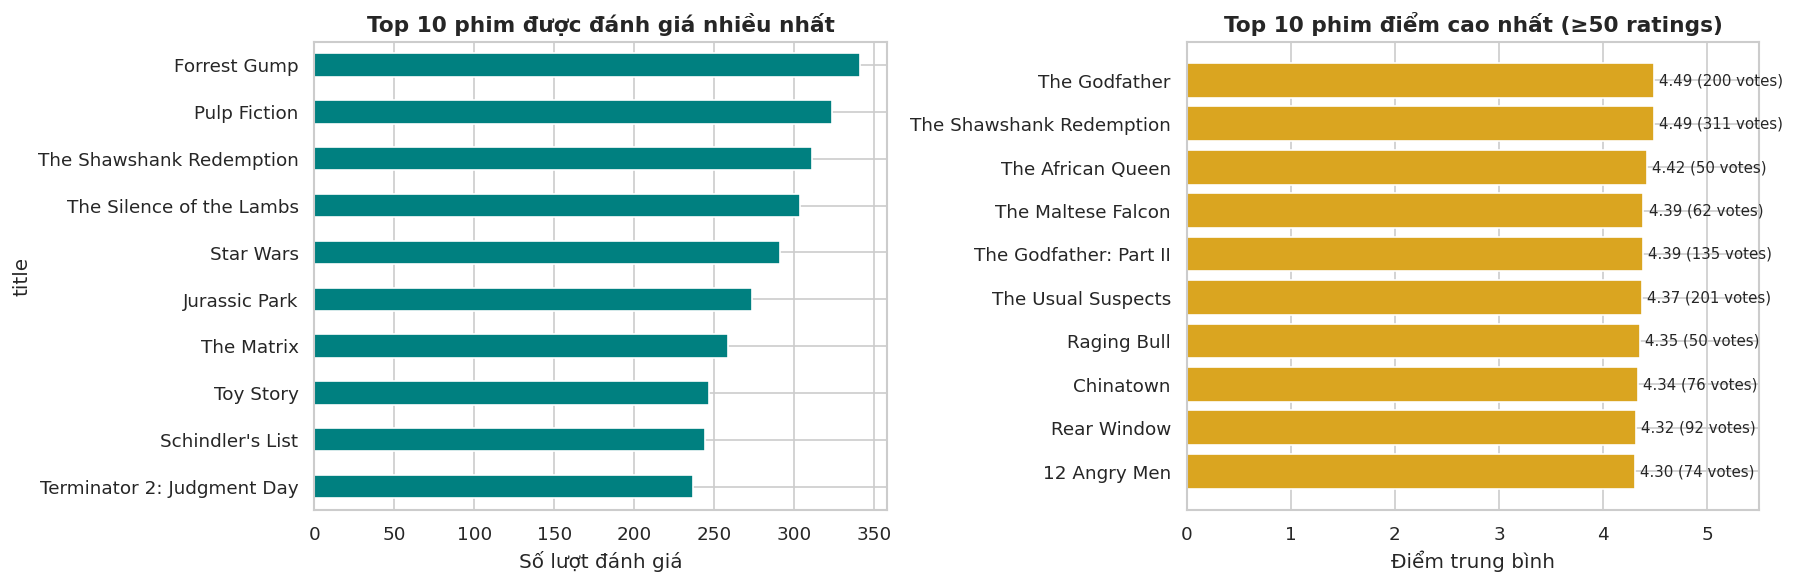

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 10 most rated
top_rated_count = (df.groupby("title")["rating"]
                   .count().sort_values(ascending=False).head(10))
top_rated_count[::-1].plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Top 10 phim được đánh giá nhiều nhất",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Số lượt đánh giá")

# Top 10 highest avg rating (min 50 ratings)
movie_stats = (ratings.groupby("movieId")["rating"]
               .agg(mean="mean", count="count").reset_index())
movie_stats  = movie_stats[movie_stats["count"] >= 50]
movie_stats  = movie_stats.merge(
    df[["movieId","title"]].drop_duplicates(), on="movieId", how="left")
top_avg = movie_stats.nlargest(10, "mean")[::-1]
axes[1].barh(top_avg["title"].str[:35], top_avg["mean"], color="goldenrod")
axes[1].set_title("Top 10 phim điểm cao nhất (≥50 ratings)",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Điểm trung bình")
axes[1].set_xlim(0, 5.5)
for i, (val, cnt) in enumerate(zip(top_avg["mean"], top_avg["count"])):
    axes[1].text(val + 0.05, i, f"{val:.2f} ({int(cnt)} votes)",
                 va="center", fontsize=9)

plt.tight_layout()
plt.show()


### 5.7 User–Movie Interaction Matrix & Sparsity

Tổng user          : 671
Tổng phim          : 9,066
Tổng ratings       : 100,004
Ma trận đầy đủ     : 671 × 9,066 = 6,083,286
Sparsity           : 98.3561%


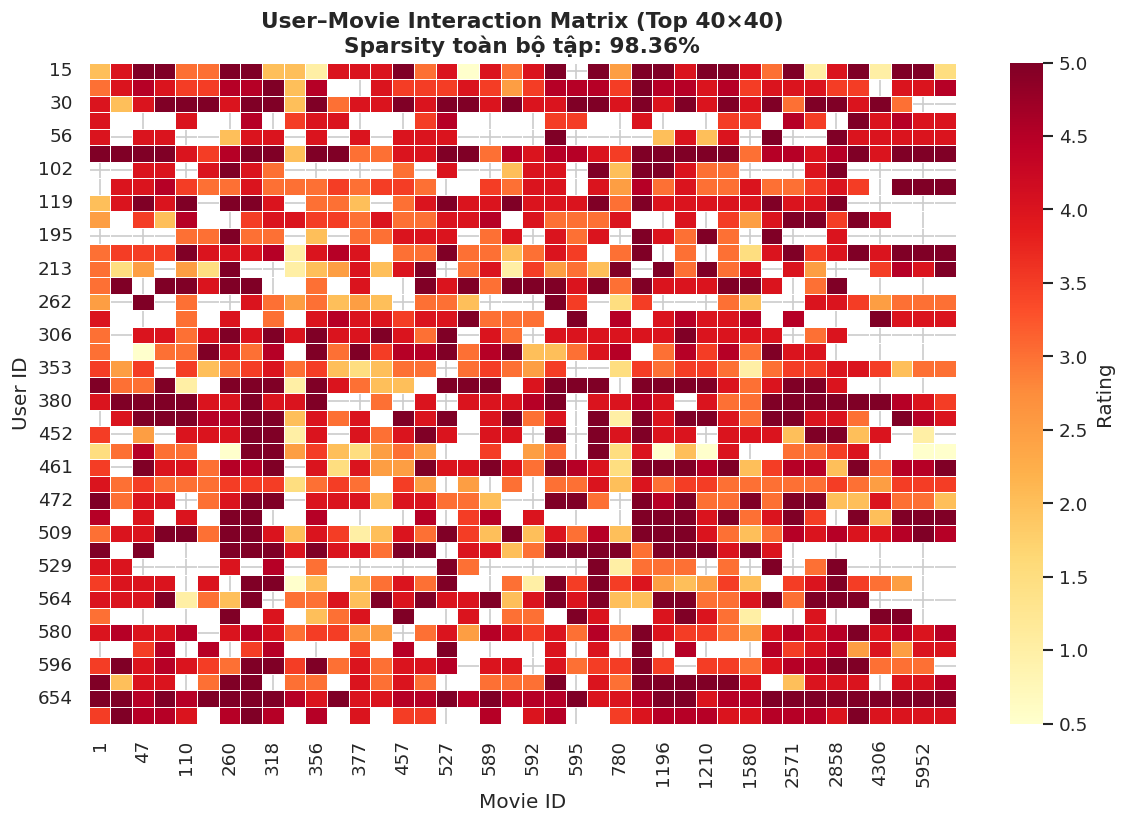

In [69]:
total_users  = ratings["userId"].nunique()
total_movies = ratings["movieId"].nunique()
sparsity     = 1 - len(ratings) / (total_users * total_movies)

print(f"Tổng user          : {total_users:,}")
print(f"Tổng phim          : {total_movies:,}")
print(f"Tổng ratings       : {len(ratings):,}")
print(f"Ma trận đầy đủ     : {total_users:,} × {total_movies:,} = {total_users*total_movies:,}")
print(f"Sparsity           : {sparsity:.4%}")

# Visualize sample 40×40
top_users_ids  = ratings["userId"].value_counts().head(40).index
top_movies_ids = ratings["movieId"].value_counts().head(40).index
sample = ratings[ratings["userId"].isin(top_users_ids) &
                 ratings["movieId"].isin(top_movies_ids)]
matrix = sample.pivot_table(index="userId", columns="movieId", values="rating")

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(matrix, cmap="YlOrRd", linewidths=0.3,
            cbar_kws={"label": "Rating"}, ax=ax)
ax.set_title(f"User–Movie Interaction Matrix (Top 40×40)\n"
             f"Sparsity toàn bộ tập: {sparsity:.2%}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Movie ID")
ax.set_ylabel("User ID")
plt.tight_layout()
plt.show()


### 5.8 Điểm đánh giá theo thể loại phim

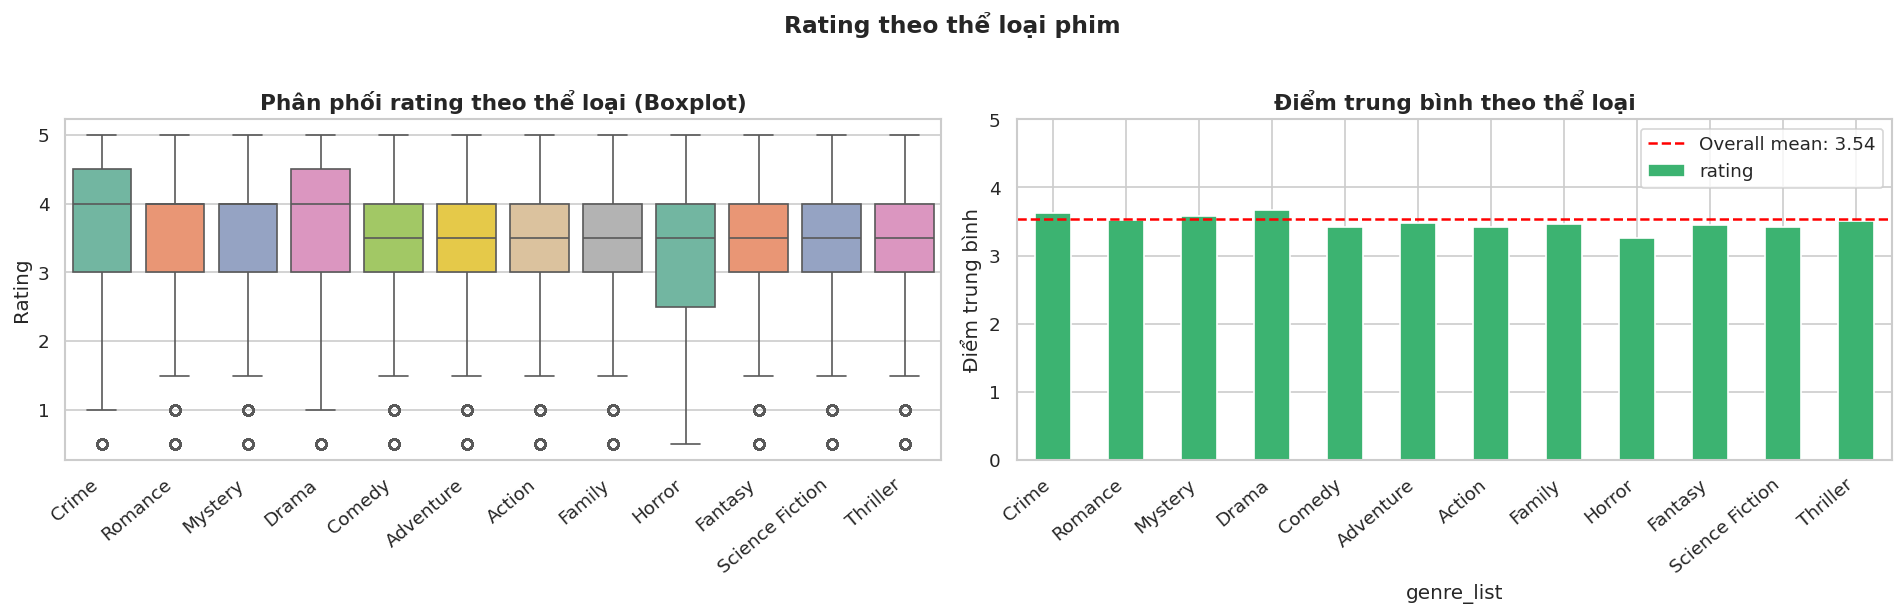

In [70]:
# Explode genre_list để mỗi hàng là 1 thể loại
genre_rating = df.explode("genre_list").dropna(subset=["genre_list"])
genre_rating  = genre_rating[genre_rating["genre_list"] != ""]

# Lấy top 12 genre
top12_genres = genre_counts.head(12).index.tolist()
genre_rating_top = genre_rating[genre_rating["genre_list"].isin(top12_genres)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot
order = (genre_rating_top.groupby("genre_list")["rating"]
         .median().sort_values(ascending=False).index)
sns.boxplot(x="genre_list", y="rating", data=genre_rating_top,
            order=order, palette="Set2", ax=axes[0])
axes[0].set_title("Phân phối rating theo thể loại (Boxplot)",
                  fontsize=13, fontweight="bold")
axes[0].set_xticklabels(order, rotation=40, ha="right")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rating")

# Mean rating bar
mean_by_genre = (genre_rating_top.groupby("genre_list")["rating"]
                 .mean().reindex(order))
mean_by_genre.plot(kind="bar", ax=axes[1], color="mediumseagreen", edgecolor="white")
axes[1].set_title("Điểm trung bình theo thể loại",
                  fontsize=13, fontweight="bold")
axes[1].set_xticklabels(order, rotation=40, ha="right")
axes[1].set_ylabel("Điểm trung bình")
axes[1].set_ylim(0, 5)
axes[1].axhline(df["rating"].mean(), color="red", linestyle="--",
                label=f"Overall mean: {df['rating'].mean():.2f}")
axes[1].legend()

plt.suptitle("Rating theo thể loại phim", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 6. Insights for Recommendation System

### 6.1 Cold Start Analyst

In [71]:
user_activity  = ratings.groupby("userId")["rating"].count()
movie_activity = ratings.groupby("movieId")["rating"].count()

thresholds = [5, 10, 20]

print("═" * 55)
print(f"{'Threshold':<12} {'Cold Users':>12} {'%':>8} {'Cold Movies':>12} {'%':>8}")
print("═" * 55)
for t in thresholds:
    cu = (user_activity  < t).sum()
    cm = (movie_activity < t).sum()
    print(f"< {t} ratings  {cu:>12,} {cu/len(user_activity):>8.1%} "
          f"{cm:>12,} {cm/len(movie_activity):>8.1%}")
print("═" * 55)
print()
print("Cold-start là thách thức lớn với Collaborative Filtering.")
print("   → Content-based (genre, metadata) giúp xử lý cold-start items.")
print("   → Hybrid model kết hợp cả hai để bù trừ nhược điểm.")


═══════════════════════════════════════════════════════
Threshold      Cold Users        %  Cold Movies        %
═══════════════════════════════════════════════════════
< 5 ratings             0     0.0%        5,570    61.4%
< 10 ratings             0     0.0%        6,821    75.2%
< 20 ratings             0     0.0%        7,763    85.6%
═══════════════════════════════════════════════════════

Cold-start là thách thức lớn với Collaborative Filtering.
   → Content-based (genre, metadata) giúp xử lý cold-start items.
   → Hybrid model kết hợp cả hai để bù trừ nhược điểm.


### 6.2 Popularity Bias

Top 1%  phim chiếm 15.9% tổng số ratings
Top 10% phim chiếm 59.9% tổng số ratings
Bottom 50% phim chỉ chiếm 6.3% tổng số ratings


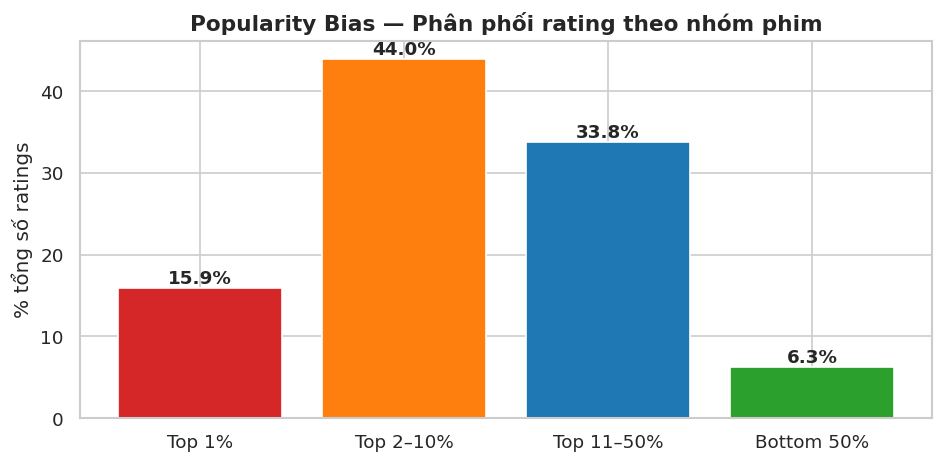


Popularity Bias khiến model thiên về gợi ý phim nổi tiếng.
   → Cần re-ranking hoặc diversity metric để cân bằng.


In [72]:
movie_pop = ratings.groupby("movieId")["rating"].count().sort_values(ascending=False)
total     = len(movie_pop)

top1pct  = movie_pop.head(int(total * 0.01)).sum() / len(ratings)
top10pct = movie_pop.head(int(total * 0.10)).sum() / len(ratings)
bot50pct = movie_pop.tail(int(total * 0.50)).sum() / len(ratings)

print(f"Top 1%  phim chiếm {top1pct:.1%} tổng số ratings")
print(f"Top 10% phim chiếm {top10pct:.1%} tổng số ratings")
print(f"Bottom 50% phim chỉ chiếm {bot50pct:.1%} tổng số ratings")

fig, ax = plt.subplots(figsize=(8, 4))
categories = ["Top 1%", "Top 2–10%", "Top 11–50%", "Bottom 50%"]
values = [
    top1pct,
    top10pct - top1pct,
    movie_pop.head(int(total*0.5)).sum()/len(ratings) - top10pct,
    bot50pct,
]
bars = ax.bar(categories, [v*100 for v in values],
              color=["#d62728","#ff7f0e","#1f77b4","#2ca02c"])
ax.set_title("Popularity Bias — Phân phối rating theo nhóm phim",
             fontsize=13, fontweight="bold")
ax.set_ylabel("% tổng số ratings")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1%}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("Popularity Bias khiến model thiên về gợi ý phim nổi tiếng.")
print("   → Cần re-ranking hoặc diversity metric để cân bằng.")


### 6.3 Rating Bias (Explicit vs Implicit Feedback)

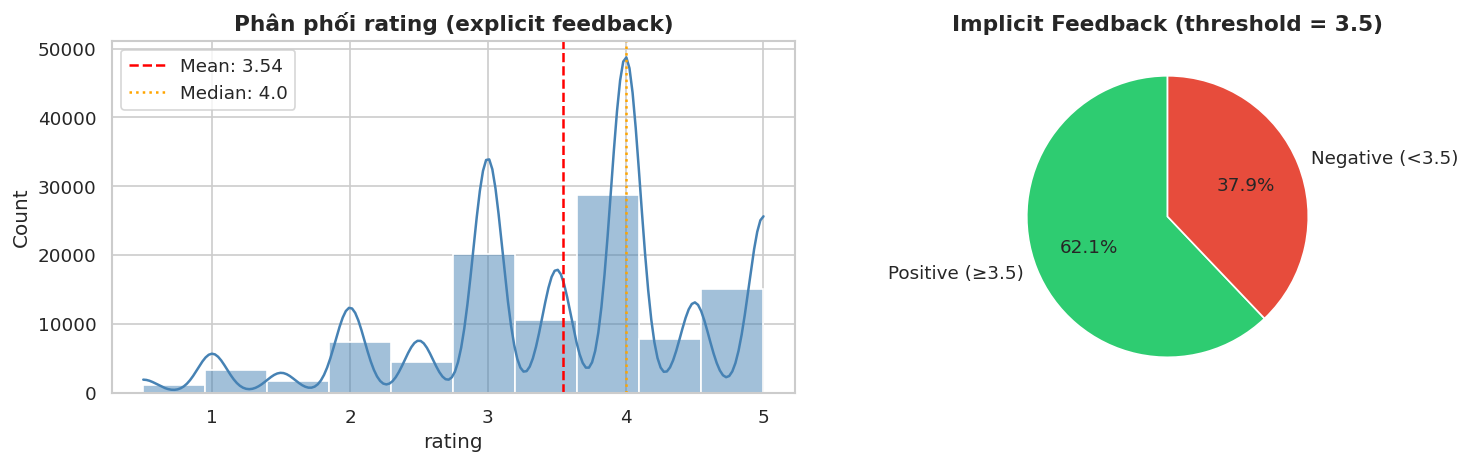

Rating có xu hướng lệch phải (positivity bias).
   → Với implicit feedback (click/view), cần xử lý khác:
   → ALS với implicit thường dùng confidence = 1 + α × rating.


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution
sns.histplot(ratings["rating"], bins=10, kde=True,
             color="steelblue", ax=axes[0])
axes[0].axvline(ratings["rating"].mean(), color="red", linestyle="--",
                label=f"Mean: {ratings['rating'].mean():.2f}")
axes[0].axvline(ratings["rating"].median(), color="orange", linestyle=":",
                label=f"Median: {ratings['rating'].median():.1f}")
axes[0].set_title("Phân phối rating (explicit feedback)",
                  fontsize=13, fontweight="bold")
axes[0].legend()

# Implicit: binarize at 3.5
ratings["implicit"] = (ratings["rating"] >= 3.5).astype(int)
imp_counts = ratings["implicit"].value_counts()
axes[1].pie(imp_counts, labels=["Positive (≥3.5)","Negative (<3.5)"]
            if imp_counts.index[0]==1 else ["Negative (<3.5)","Positive (≥3.5)"],
            autopct="%1.1f%%", colors=["#2ecc71","#e74c3c"],
            startangle=90)
axes[1].set_title("Implicit Feedback (threshold = 3.5)",
                  fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print("Rating có xu hướng lệch phải (positivity bias).")
print("   → Với implicit feedback (click/view), cần xử lý khác:")
print("   → ALS với implicit thường dùng confidence = 1 + α × rating.")


### 6.4 Sparsity & Scalability Summary

In [74]:
total_users  = ratings["userId"].nunique()
total_movies = ratings["movieId"].nunique()
sparsity     = 1 - len(ratings) / (total_users * total_movies)

summary = {
    "Tổng số ratings"     : f"{len(ratings):,}",
    "Số user"             : f"{total_users:,}",
    "Số phim"             : f"{total_movies:,}",
    "Sparsity"            : f"{sparsity:.4%}",
    "Avg ratings/user"    : f"{ratings.groupby('userId')['rating'].count().mean():.1f}",
    "Avg ratings/movie"   : f"{ratings.groupby('movieId')['rating'].count().mean():.1f}",
    "Rating range"        : f"{ratings['rating'].min()} – {ratings['rating'].max()}",
    "Rating mean"         : f"{ratings['rating'].mean():.3f}",
}

print("╔══════════════════════════════════════════════════╗")
print("║         DATASET SUMMARY FOR RECOMMENDER          ║")
print("╠══════════════════════════════════════════════════╣")
for k, v in summary.items():
    print(f"║  {k:<26}: {v:<20}║")
print("╚══════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════╗
║         DATASET SUMMARY FOR RECOMMENDER          ║
╠══════════════════════════════════════════════════╣
║  Tổng số ratings           : 100,004             ║
║  Số user                   : 671                 ║
║  Số phim                   : 9,066               ║
║  Sparsity                  : 98.3561%            ║
║  Avg ratings/user          : 149.0               ║
║  Avg ratings/movie         : 11.0                ║
║  Rating range              : 0.5 – 5.0           ║
║  Rating mean               : 3.544               ║
╚══════════════════════════════════════════════════╝
